# Evaluation and Visualization for Clustering


In this section, we represent the semantic distances between concepts using traditional computational methods and evaluate the reasonableness of the results.

We have clustered three types of embeddings that had been reduced in dimensionality using PCA (details of the PCA process can be found in `clean_data_new.ipynb`). For distance calculations, we employed both cosine distance and Euclidean distance, using K-Medoids as the clustering method. After evaluating the clustering results, we selected the best-performing distance calculation method as the semantic distance measure. Finally, we computed the semantic distances between consecutive concepts along each path.

#### Environment Setup

In [1]:
# Suppress warnings
import warnings
warnings.filterwarnings('ignore')

# Add custom module path
import sys
sys.path.append("./src/semantic")

# Standard library imports
import re

# Third-party library imports
import numpy as np
import pickle
import pandas as pd
from scipy.spatial.distance import cosine
from scipy.spatial.distance import cdist
import matplotlib.pyplot as plt
import seaborn as sns

# Semantic analysis scripts
from src.semantic.perform_clustering import (
    run_all_clustering, 
    run_kimchi_cos,
    run_all_clustering_with_pca
)
from src.semantic.utils.evaluate_clustering import (
    calculate_clustering_consistency,
    get_primary_category,
    map_clustering_category,
    calculate_cluster_distances
)


## Explore Different Measures of Semantic Distance

### Text Embedding

In [2]:
# Path to the category data file
category_file = './/data//wikispeedia//wikispeedia_paths-and-graph//categories.tsv'

## All paths to the embedding data files
# This time we use the new embedding data, generated with the first paragraph for each article.
MiniLM_file = './/new_data_cleaning//pca_MiniLM_dimensions.pkl' 
mpnet_file = './/new_data_cleaning//pca_mpnet_dimensions.pkl' 
roberta_file = './/new_data_cleaning//pca_Roberta_dimensions.pkl'

In [3]:
with open(MiniLM_file, "rb") as file:
        MiniLM_embedding = pickle.load(file)
        MiniLM_values = list(MiniLM_embedding.values())
with open(mpnet_file, "rb") as file:
        mpnet_embedding = pickle.load(file)
        mpnet_values = list(mpnet_embedding.values())
with open(roberta_file, "rb") as file:
        roberta_embedding = pickle.load(file)
        roberta_values = list(roberta_embedding.values())

## Semantic Measure Evaluation: Clustering on Embeddings

In [4]:
# For embeddings generated from MiniLM
print('------Starting clustering for embeddings based on MiniLM_L6_v2...')
MiniLM_clustering = run_all_clustering(MiniLM_file, category_file)
print(f"Perform {list(MiniLM_clustering.keys())} successfully!")

# For embeddings generated from mpnet_base_v2
print('------Starting clustering for embeddings based on mpnet_base_v2...')
mpnet_clustering = run_all_clustering(mpnet_file, category_file)
print(f"Perform {list(mpnet_clustering.keys())} successfully!")

# Cluster embeddings generated from roberta
print('------Starting clustering for embeddings based on roberta...')
roberta_clustering = run_all_clustering(roberta_file, category_file)
print(f"Perform {list(roberta_clustering.keys())} successfully!")

------Starting clustering for embeddings based on MiniLM_L6_v2...
15 categories found in wikispeedia.


100%|██████████| 2/2 [00:00<00:00,  2.10it/s]


Perform ['K-Medoids_Manhattan', 'K-Medoids_Cosine'] successfully!
------Starting clustering for embeddings based on mpnet_base_v2...
15 categories found in wikispeedia.


100%|██████████| 2/2 [00:01<00:00,  1.89it/s]


Perform ['K-Medoids_Manhattan', 'K-Medoids_Cosine'] successfully!
------Starting clustering for embeddings based on roberta...
15 categories found in wikispeedia.


100%|██████████| 2/2 [00:00<00:00,  3.46it/s]

Perform ['K-Medoids_Manhattan', 'K-Medoids_Cosine'] successfully!


the clustering results is stored as follows:

- **MiniLM_clustering**
  - **K-Medoids Manhattan**: Embeddings (DataFrame)
  - **K-Medoids Cosine**: Embeddings (DataFrame)

In [5]:
# A sample of clustering results
MiniLM_clustering['K-Medoids_Manhattan'].head(5)

,concept,clustering
0,%C3%81ed%C3%A1n_mac_Gabr%C3%A1in,0
1,%C3%85land,0
2,%C3%89douard_Manet,1
3,%C3%89ire,6
4,%C3%93engus_I_of_the_Picts,0


### Category-Cluster Mapping and Evaluation

- This method calculates the Inter-Cluster Distance, Intra-Cluster Distance, Purity and Entropy for the Category-Cluster Mapping. 
- First, the cluster-category mapping is sorted in descending order based on their mapping counts and then uniquely matched (each cluster corresponds to only one category, and each category corresponds to only one cluster).
- **Inter-Cluster Distance** measures the average distance between the centers of different clusters; higher values are better as they signify greater separation and distinctness between clusters.
- **Intra-Cluster Distance** measures the average distance between points within the same cluster and their respective cluster center; lower values are better as they indicate tighter, more cohesive clusters.
- **Purity** indicates the extent to which each cluster contains points from a single ground truth class; higher values are better as they signify cleaner and more distinct clusters.
- **Entropy** quantifies the randomness or disorder within the clustering; lower values are better as they indicate more consistent and cohesive clusters.


In [11]:
# Get primary categories for concepts and show the head
primary_category = get_primary_category(category_file)
primary_category.head(5)

,concept,primary_category
0,%C3%81ed%C3%A1n_mac_Gabr%C3%A1in,History
1,%C3%81ed%C3%A1n_mac_Gabr%C3%A1in,People
2,%C3%85land,Countries
3,%C3%85land,Geography
4,%C3%89douard_Manet,People


In [12]:
# Set dicts to save the mapping results
MiniLM_evaluation = {}
mpnet_evaluation = {}
roberta_evaluation = {}
MiniLM_mapping = {}
mpnet_mapping = {}
roberta_mapping = {}

# Set df to save the evaluation results
MiniLM_eva_df = pd.DataFrame(columns=['inter_distance','intra_distance','purity','entropy'])
mpnet_eva_df = pd.DataFrame(columns=['inter_distance','intra_distance','purity','entropy'])
roberta_eva_df = pd.DataFrame(columns=['inter_distance','intra_distance','purity','entropy'])

# evaluation on MiniLM_L6_v2
print("------Evaluation results for MiniLM embeddings:")
for key, value in MiniLM_clustering.items():

    # Calculate the purity and entropy
    cluster_category_mapping, merged_df, purity,entropy = map_clustering_category(primary_category, value)
    MiniLM_mapping[key] = cluster_category_mapping
    MiniLM_evaluation[key] = merged_df

    # Calculate the inter cluster distance or intra cluster distance
    data = np.array(MiniLM_values).astype(np.float64)
    labels = np.array(value['clustering'])
    avg_inter_dist, avg_intra_dist = calculate_cluster_distances(data, labels, 15)

    MiniLM_eva_df.loc[len(MiniLM_eva_df)] = [avg_inter_dist, avg_intra_dist, purity, entropy]
    
MiniLM_eva_df.index = ['K-Medoids_Manhattan', 'K-Medoids_Cosine']
print(MiniLM_eva_df)

# evaluation on mpnet_base_v2
print("------Evaluation results for mpnet embeddings:")
for key, value in mpnet_clustering.items():

    # Calculate the purity and entropy
    cluster_category_mapping, merged_df, purity,entropy = map_clustering_category(primary_category, value)
    mpnet_mapping[key] = cluster_category_mapping
    mpnet_evaluation[key] = merged_df

    # Calculate the inter cluster distance or intra cluster distance
    data = np.array(mpnet_values).astype(np.float64)
    labels = np.array(value['clustering'])
    avg_inter_dist, avg_intra_dist = calculate_cluster_distances(data, labels, 15)
    mpnet_eva_df.loc[len(mpnet_eva_df)] = [avg_inter_dist, avg_intra_dist, purity, entropy]
mpnet_eva_df.index = ['K-Medoids_Manhattan', 'K-Medoids_Cosine']
print(mpnet_eva_df)

# evaluation on mpnet_base_v2
print("------Evaluation results for roberta embeddings:")
for key, value in roberta_clustering.items():

    # Calculate the purity and entropy
    cluster_category_mapping, merged_df, purity,entropy = map_clustering_category(primary_category, value)
    roberta_mapping[key] = cluster_category_mapping
    roberta_evaluation[key] = merged_df

    # Calculate the inter cluster distance or intra cluster distance
    data = np.array(roberta_values).astype(np.float64)
    labels = np.array(value['clustering'])
    roberta_eva_df.loc[len(roberta_eva_df)] = [avg_inter_dist, avg_intra_dist, purity, entropy]
roberta_eva_df.index = ['K-Medoids_Manhattan', 'K-Medoids_Cosine']
print(roberta_eva_df)

------Evaluation results for MiniLM embeddings:
                     inter_distance  intra_distance    purity   entropy
K-Medoids_Manhattan        0.422215        0.768586  0.350692  2.821583
K-Medoids_Cosine           0.449608        0.750201  0.459839  2.360897
------Evaluation results for mpnet embeddings:
                     inter_distance  intra_distance    purity   entropy
K-Medoids_Manhattan        0.435769        0.754004  0.378939  2.787256
K-Medoids_Cosine           0.453174        0.743187  0.512683  2.248699
------Evaluation results for roberta embeddings:
                     inter_distance  intra_distance    purity   entropy
K-Medoids_Manhattan        0.453174        0.743187  0.328786  2.973449
K-Medoids_Cosine           0.453174        0.743187  0.446003  2.553098


The performance is suboptimal, and the possible reasons are as follows:

- **Insufficient Embedding Representation**: Although the selected embedding models (MiniLM, mpnet, and roberta) can capture semantic information, they may not effectively differentiate between categories in the clustering task.

- **Poor Clustering Performance in High-Dimensional Space**: Despite applying PCA for dimensionality reduction, the embeddings still retain dimensions between 50 and 100. High-dimensional data often suffers from the "curse of dimensionality," where Euclidean or cosine distance metrics become less effective.

- **Limitations of the Clustering Algorithm**: The clustering algorithm itself has certain limitations and may fail to accurately group the data based on semantic representations.

- **Limitations of the Number of Clusters**: To align with the primary categories, the number of clusters was preset to match the number of categories (15). However, this assumption may not reflect the actual distribution of the data.

Based on the evaluataion results, we finally choose **mpnet embeddings** with the **Cosine Distance** as our semantic distance, as it has the best performance.

## Visualize the clustering result

In [22]:
## As an embedding has many dimensions, we can select two dimensions and draw the distribution.
# Choose two dimensions: d1, d2. We can set two dimensions freely.
d1=0
d2=10
mpnet_values_array = np.array(mpnet_values)[:, [d1, d2]]
mpnet_df = pd.DataFrame(mpnet_values_array, columns=["d1", "d2"])
mpnet_df['clustering'] = mpnet_clustering['K-Medoids_Cosine']['clustering']
mpnet_df['clustering'] = mpnet_df['clustering'].apply(lambda x: str(x)+'-'+mpnet_mapping['K-Medoids_Cosine'][x])
# A sample of the data
mpnet_df.head(5)

,d1,d2,clustering
0,-0.097535,-0.170014,14-History
1,0.101630,0.089937,9-Mathematics
2,-0.197396,-0.123021,2-Language_and_literature
3,-0.024681,-0.028492,4-Citizenship
4,-0.082867,-0.155100,14-History


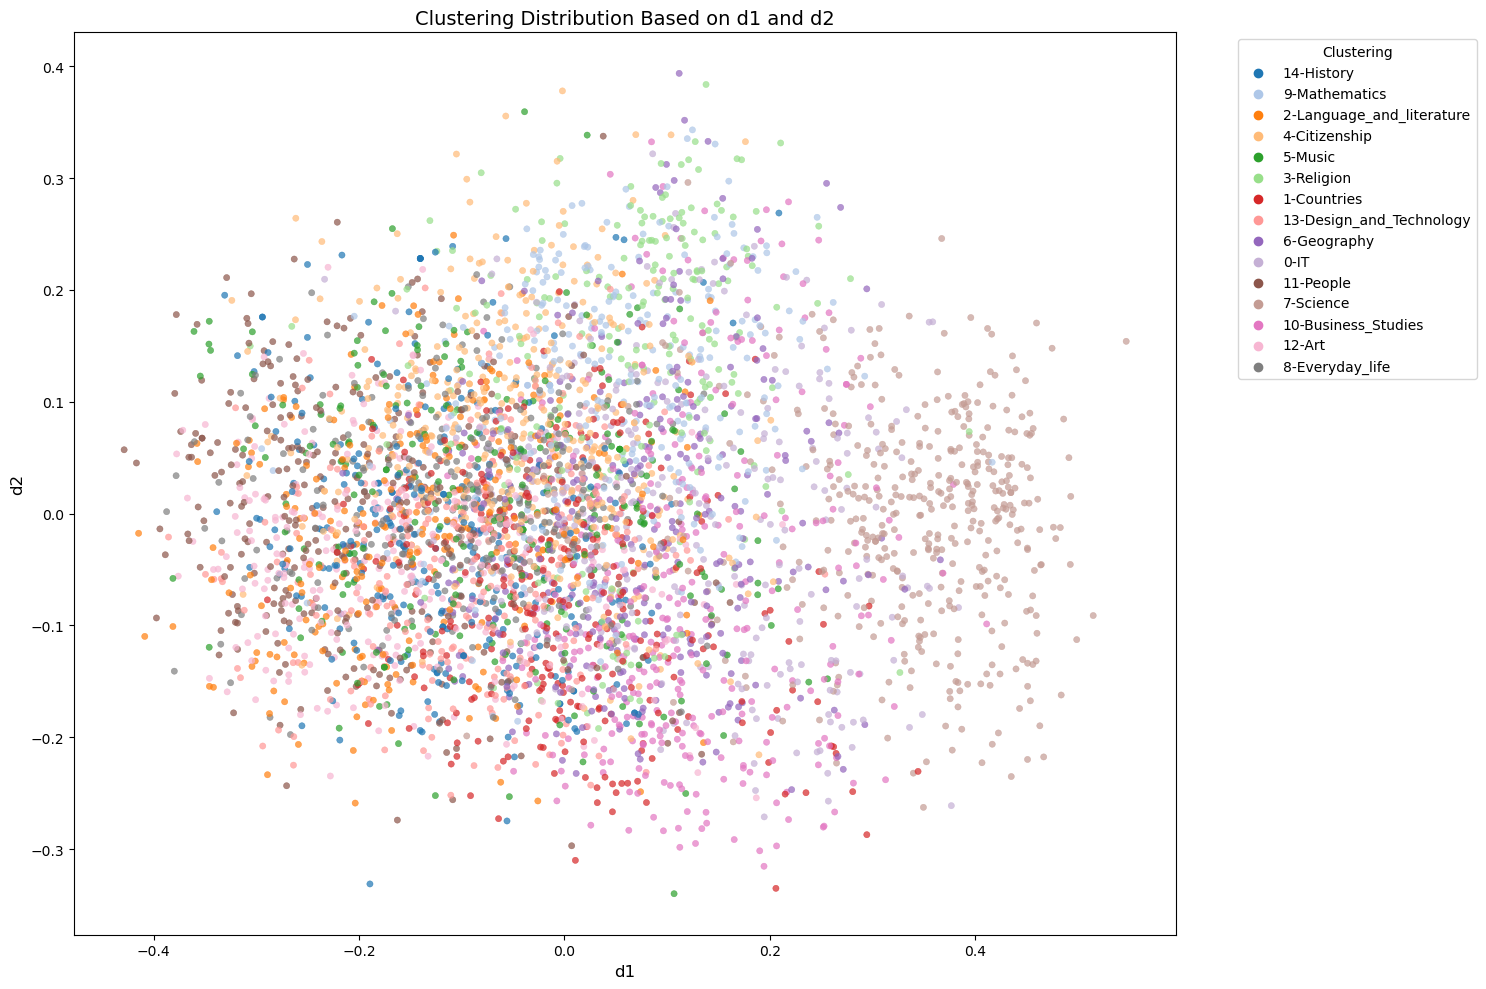

In [31]:
d1=0
d2=7
mpnet_values_array = np.array(mpnet_values)[:, [d1, d2]]
mpnet_df = pd.DataFrame(mpnet_values_array, columns=["d1", "d2"])
mpnet_df['clustering'] = mpnet_clustering['K-Medoids_Cosine']['clustering']
mpnet_df['clustering'] = mpnet_df['clustering'].apply(lambda x: str(x)+'-'+mpnet_mapping['K-Medoids_Cosine'][x])
# A sample of the data

# Plot a scatter plot using Seaborn
plt.figure(figsize=(15, 10))
scatter = sns.scatterplot(
    x='d1',                     # Use 'd1' for the x-axis
    y='d2',                     # Use 'd2' for the y-axis
    hue='clustering',           # Color points based on the 'clustering' column
    palette='tab20',             # Use the 'husl' palette for distinct and rich colors
    data=mpnet_df,             # Input DataFrame
    s=20,                       # Adjust the point size
    alpha=0.7,                  # Set transparency to avoid excessive overlap
    edgecolor=None              # Remove the border around points
)

# Add titles and axis labels
plt.title('Clustering Distribution Based on d1 and d2', fontsize=14)
plt.xlabel('d1', fontsize=12)
plt.ylabel('d2', fontsize=12)

# Adjust the legend position for better visibility
plt.legend(title='Clustering', bbox_to_anchor=(1.05, 1), loc='upper left')

# Optimize layout to prevent overlap
plt.tight_layout()

# Display the plot
plt.show()

## Visualize the semantic path
We can use the cosine distance to represent the semantic distance and visualize each navigation.

In [13]:
# First we need to calculate the semantic distance between each two concepts
# Extract concept names and embeddings
concept_names = list(mpnet_embedding.keys())
embeddings = np.array(list(mpnet_embedding.values()))

# Create an empty list to store results
results = []

# Compute cosine distances between every pair of concepts
num_concepts = len(concept_names)
for i in range(num_concepts):
    for j in range(i + 1, num_concepts):  # Ensure (a, b) is not duplicated as (b, a)
        concept_1 = concept_names[i]
        concept_2 = concept_names[j]
        distance = cosine(embeddings[i], embeddings[j])
        results.append((concept_1, concept_2, distance))

# Convert results to a DataFrame
distance_df = pd.DataFrame(results, columns=["Concept 1", "Concept 2", "Distance"])

In [15]:
# Define the file path
file_path = "data//wikispeedia//wikispeedia_paths-and-graph//paths_finished.tsv"  # Replace with your file path

# Read the data: skip lines starting with "#" (comments)
path_df = pd.read_csv(file_path, sep='\t', comment='#', header=None, 
                      names=["hashedIpAddress", "timestamp", "durationInSec", "path", "rating"])

# Replace "NULL" with NaN to handle missing values
path_df["rating"] = path_df["rating"].replace("NULL", pd.NA)

# Print the first 3 rows of the DataFrame
path_df.head(3)

,hashedIpAddress,timestamp,durationInSec,path,rating
0,6a3701d319fc3754,1297740409,166,14th_century;15th_century;16th_century;Pacific...,NaN
1,3824310e536af032,1344753412,88,14th_century;Europe;Africa;Atlantic_slave_trad...,3.0
2,415612e93584d30e,1349298640,138,14th_century;Niger;Nigeria;British_Empire;Slav...,NaN


In [16]:
# Example dataset containing paths

# Calculate the length of each path (number of concepts separated by ";")
path_df['path_length'] = path_df['path'].apply(lambda x: len(x.split(';')))

# Count the number of paths for each length
length_counts = path_df['path_length'].value_counts().sort_index()
length_counts = length_counts[length_counts>2000]

# Print the results
print("Path length counts:")
print(length_counts)

Path length counts:
3     3424
4     8558
5    10941
6     8137
7     5868
8     3954
9     2650
Name: path_length, dtype: int64


We select only paths with lengths between 3 and 9 and sample 10 paths for each length to generate the plot.

In [17]:
# Convert semantic distance data to a dictionary for fast lookups
distance_dict = {}
for _, row in distance_df.iterrows():
    distance_dict[(row['Concept 1'], row['Concept 2'])] = row['Distance']
    distance_dict[(row['Concept 2'], row['Concept 1'])] = row['Distance']  # Ensure symmetry

# Compute semantic distances for each path
def compute_path_distances(path, distance_dict, default_distance=0.5):
    concepts = path.split(';')
    distances = []
    for i in range(len(concepts) - 1):
        concept_pair = (concepts[i], concepts[i + 1])
        distance = distance_dict.get(concept_pair, default_distance)  # Use default if pair not found
        distances.append(distance)
    return distances

# Process all paths and group them by path length
path_lengths = []
path_distances = []
for path in path_df['path']:
    distances = compute_path_distances(path, distance_dict)
    path_lengths.append(len(distances))  # Length is the number of distances
    path_distances.append(distances)

# Convert path lengths and distances into a DataFrame for easy sampling
path_data = pd.DataFrame({'length': path_lengths, 'distances': path_distances})

# Filter paths to include only specified lengths and sample 10 paths for each length
filtered_lengths = [3, 4, 5, 6, 7, 8, 9]
sampled_paths = (
    path_data[path_data['length'].isin(filtered_lengths)]
    .groupby('length')
    .apply(lambda x: x.sample(min(len(x), 10), random_state=42))
    .reset_index(drop=True)
)

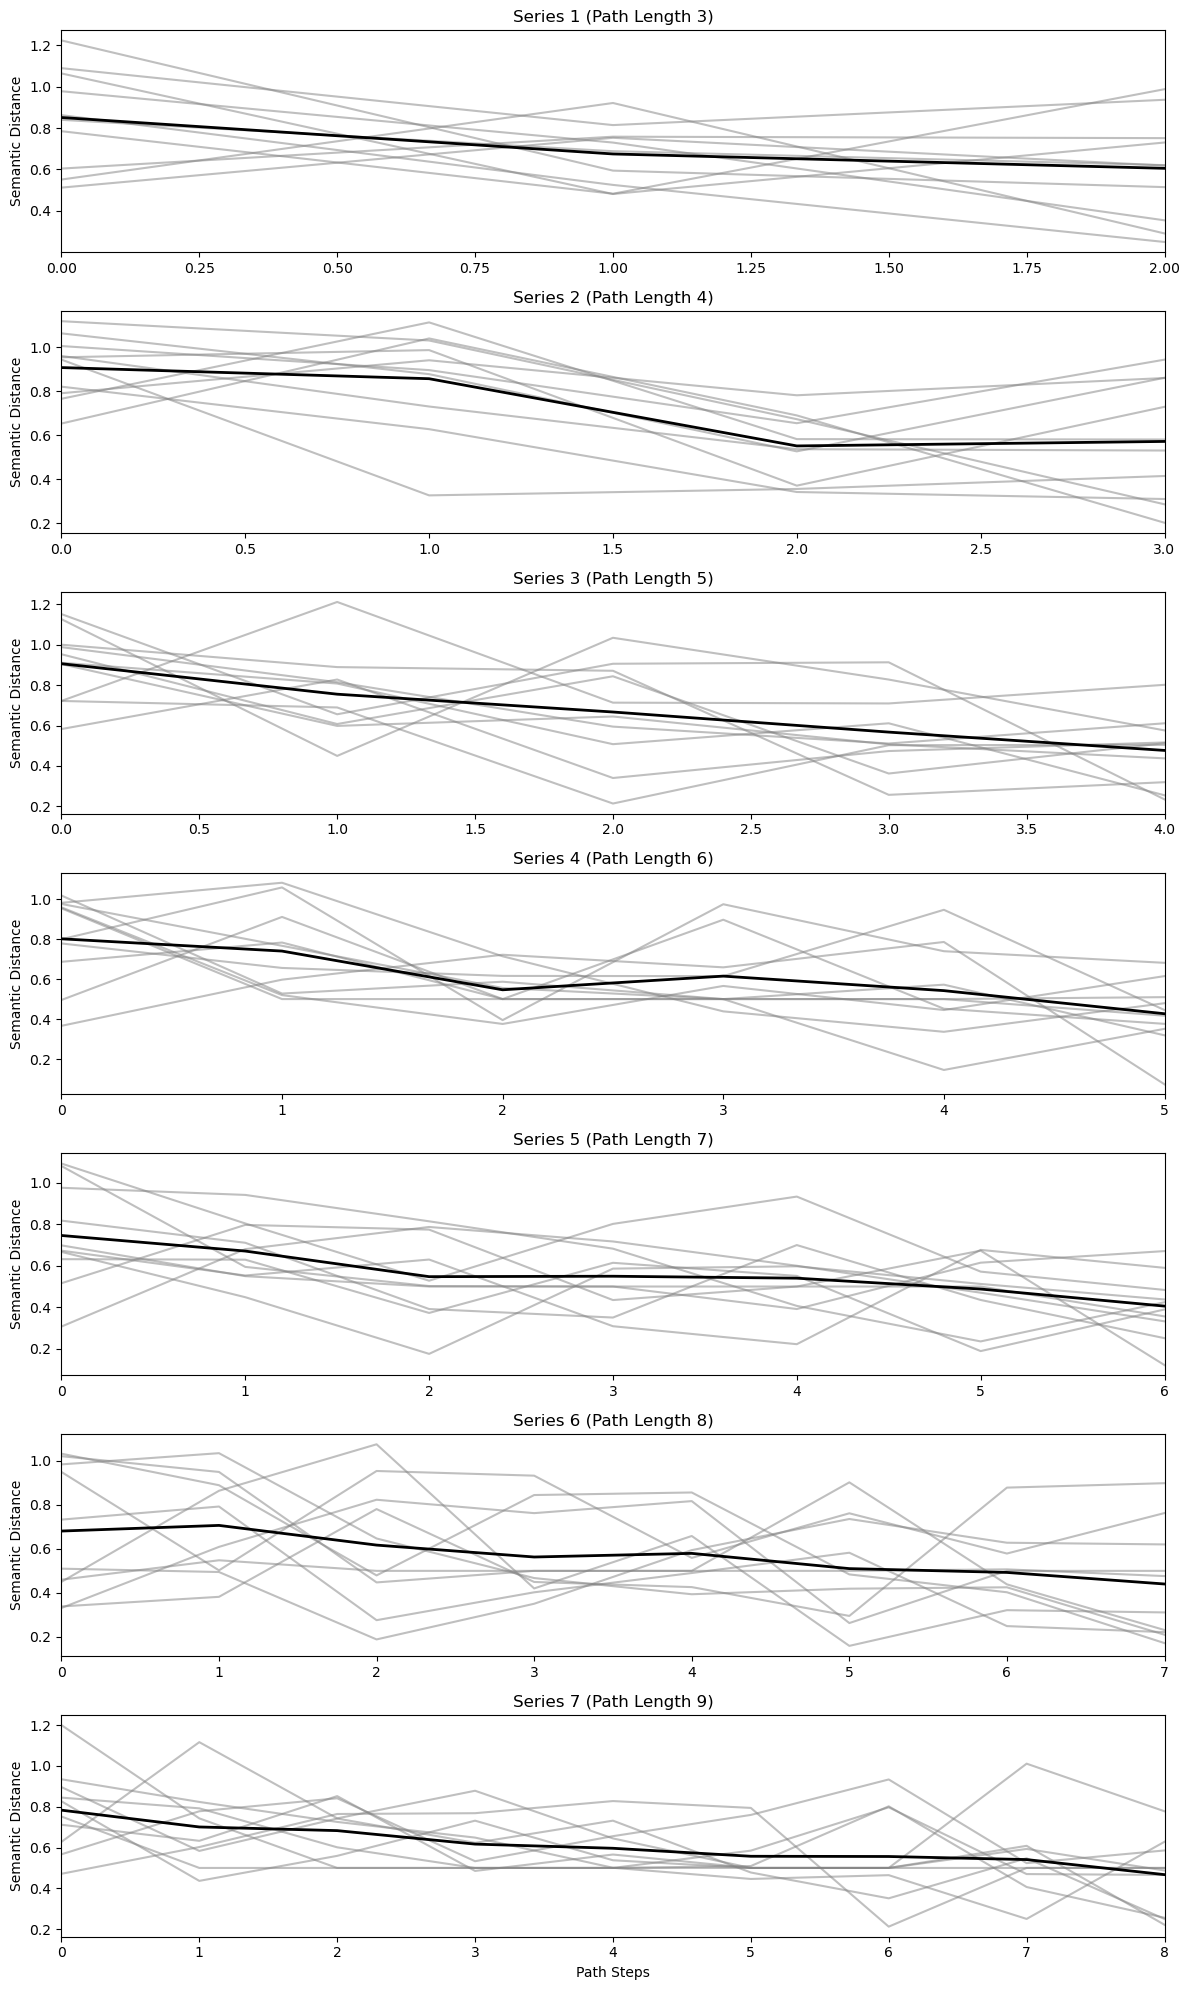

In [20]:
# Visualization
# Group sampled paths by their lengths
unique_lengths = sorted(sampled_paths['length'].unique())

plt.figure(figsize=(12, 20))  # Overall figure size

# Plot each group in a subplot
for idx, length in enumerate(unique_lengths):
    plt.subplot(len(unique_lengths), 1, idx + 1)
    plt.title(f"Series {idx + 1} (Path Length {length})")
    
    # Extract paths of this length
    length_group = sampled_paths[sampled_paths['length'] == length]['distances']
    
    # Plot sampled paths
    for distances in length_group:
        plt.plot(distances, color='gray', alpha=0.5)  # Plot background paths
    
    # Highlight the average path
    avg_distances = np.mean(length_group.tolist(), axis=0)
    plt.plot(avg_distances, color='black', linewidth=2)  # Highlight average line
    
    plt.xlim(0, length - 1)
    plt.ylabel('Semantic Distance')

# Add x-axis label
plt.xlabel('Path Steps')
plt.tight_layout()
plt.show()

## Generate semantic distance for all paths

In [28]:
# Get the maximum path_length as the total number of step columns
max_steps = path_df['path_length'].max()

# Define a function to split the path into step1, step2, ..., stepN
def split_path_to_steps(row, max_steps):
    steps = row['path'].split(';')  # Split the path string by ";"
    steps += [None] * (max_steps - len(steps))  # Pad with None to match the maximum length
    return steps

# Apply the split function to each row in the 'path' column
path_steps = path_df.apply(split_path_to_steps, max_steps=max_steps, axis=1)

# Convert the split steps into a new DataFrame
steps_df = pd.DataFrame(path_steps.tolist(), columns=[f'step{i+1}' for i in range(max_steps)])

# Combine the hashedIpAddress column with the step columns
path_df_a = pd.concat([path_df['hashedIpAddress'], steps_df], axis=1)

# Display the first 5 rows of the resulting DataFrame
path_df_a.head(5)

,hashedIpAddress,step1,step2,step3,step4,step5,step6,step7,step8,step9,...,step426,step427,step428,step429,step430,step431,step432,step433,step434,step435
0,6a3701d319fc3754,14th_century,15th_century,16th_century,Pacific_Ocean,Atlantic_Ocean,Accra,Africa,Atlantic_slave_trade,African_slave_trade,...,None,None,None,None,None,None,None,None,None,None
1,3824310e536af032,14th_century,Europe,Africa,Atlantic_slave_trade,African_slave_trade,None,None,None,None,...,None,None,None,None,None,None,None,None,None,None
2,415612e93584d30e,14th_century,Niger,Nigeria,British_Empire,Slavery,Africa,Atlantic_slave_trade,African_slave_trade,None,...,None,None,None,None,None,None,None,None,None,None
3,64dd5cd342e3780c,14th_century,Renaissance,Ancient_Greece,Greece,None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,None
4,015245d773376aab,14th_century,Italy,Roman_Catholic_Church,HIV,Ronald_Reagan,President_of_the_United_States,John_F._Kennedy,None,None,...,None,None,None,None,None,None,None,None,None,None


In [29]:
# Convert the distance dataset to a dictionary, ensuring symmetry for Concept 1 and Concept 2
distance_dict = {}
for _, row in distance_df.iterrows():
    distance_dict[(row['Concept 1'], row['Concept 2'])] = row['Distance']
    distance_dict[(row['Concept 2'], row['Concept 1'])] = row['Distance']  # Add reverse pair for symmetry

# Define a function to compute distances between consecutive steps in a path
def compute_step_distances(row, distance_dict):
    steps = row.dropna().tolist()[1:]  # Extract steps, excluding the hashedIpAddress
    step_distances = []
    for i in range(len(steps) - 1):
        concept_pair = (steps[i], steps[i + 1])
        # Retrieve distance; if not found, assign NaN
        distance = distance_dict.get(concept_pair, np.nan)
        step_distances.append(distance)
    return step_distances

# Apply the function to each row in the path DataFrame
step_distances_list = path_df_a.apply(lambda row: compute_step_distances(row, distance_dict), axis=1)

# Find the maximum number of steps across all paths to define column names
max_steps = max(len(steps) for steps in step_distances_list)
distance_columns = [f'distance_{i+1}' for i in range(max_steps)]  # Create distance column names

# Convert the list of step distances into a new DataFrame
new_path_df = pd.DataFrame(step_distances_list.tolist(), columns=distance_columns)

# Insert the hashedIpAddress column at the beginning of the new DataFrame
new_path_df.insert(0, 'hashedIpAddress', path_df['hashedIpAddress'])

# Display the resulting DataFrame
new_path_df.head(5)

,hashedIpAddress,distance_1,distance_2,distance_3,distance_4,distance_5,distance_6,distance_7,distance_8,distance_9,...,distance_425,distance_426,distance_427,distance_428,distance_429,distance_430,distance_431,distance_432,distance_433,distance_434
0,6a3701d319fc3754,0.287136,0.200664,0.923314,0.316410,0.956554,0.648317,0.668944,0.290415,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,3824310e536af032,0.720812,0.658616,0.668944,0.290415,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,415612e93584d30e,0.905302,0.286958,0.816353,0.874601,0.794856,0.668944,0.290415,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,64dd5cd342e3780c,0.694240,0.699180,0.224541,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,015245d773376aab,0.798079,0.634402,0.930160,1.001984,0.711756,0.597729,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [30]:
# Save the data
new_path_df.to_csv("new_data_cleaning//step_distances.csv", index=False,encoding='utf-8-sig')